##**Sales Data Analysis Project**

###**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQL

###**Objective**
Analyze sales data to identify revenue trends, profit drivers, top-performing products, customer purchasing patterns, and regional performance.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Python_ALB/Resume Project/sales_data.csv')

In [3]:
df.head()

,order_id,order_date,customer_Name,city,region,product,category,quantity,unit_Price,discount_Percent,total_sales,profit,payment_method,sales_channel,sales_rep
0,ORD00001,16-08-2024,Mark Hodge,Chicago,North,Mouse,Accessories,1,1176,5,1117.2,429.38,Cash,Online,Isaac Day
1,ORD00002,05-04-2024,Rhonda Chavez,Detroit,North,Smartwatch,Wearables,7,180,0,1260.0,498.12,Cash,Online,Rachel Roberson
2,ORD00003,26-08-2025,Daniel Dean,Minneapolis,North,Camera,Electronics,7,952,15,5664.4,1535.73,Debit Card,Retail Store,Nicholas Chaney
3,ORD00004,10-12-2024,Stephanie Wallace,Los Angeles,West,Tablet,Electronics,5,686,5,3258.5,1284.35,Credit Card,Retail Store,Shelly Murray
4,ORD00005,15-04-2025,Rick Ruiz,San Diego,West,Tablet,Electronics,10,1133,0,11330.0,3579.60,Credit Card,Retail Store,Jacqueline Williams


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5005 non-null   object 
 1   order_date        5005 non-null   object 
 2   customer_Name     5005 non-null   object 
 3   city              5010 non-null   object 
 4   region            5010 non-null   object 
 5   product           5010 non-null   object 
 6   category          5010 non-null   object 
 7   quantity          5010 non-null   object 
 8   unit_Price        5010 non-null   int64  
 9   discount_Percent  5010 non-null   int64  
 10  total_sales       5010 non-null   float64
 11  profit            5010 non-null   float64
 12  payment_method    5010 non-null   object 
 13  sales_channel     5010 non-null   object 
 14  sales_rep         5010 non-null   object 
dtypes: float64(2), int64(2), object(11)
memory usage: 587.2+ KB


In [5]:
df.isnull().sum()

,0
order_id,5
order_date,5
customer_Name,5
city,0
region,0
product,0
category,0
quantity,0
unit_Price,0
discount_Percent,0


In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df.describe()

,unit_Price,discount_Percent,total_sales,profit
count,5010.000000,5010.000000,5010.000000,5010.000000
mean,1341.427745,9.996008,6263.249840,1564.105661
std,3106.598721,7.015795,5120.448679,1578.615282
min,50.000000,0.000000,55.250000,1.080000
25%,667.000000,5.000000,2029.350000,404.440000
50%,1275.000000,10.000000,4826.000000,1032.665000
75%,1866.750000,15.000000,9373.875000,2230.712500
max,125000.000000,20.000000,24810.000000,10374.200000


##**Data Cleaning**

**The following steps were performed:**

- Checked missing values
- Checked duplicate records
- Removed duplicate order IDs
- Converted date columns to datetime format
- Converted numerical columns to appropriate data types
- Validated data quality before analysis

In [8]:
# Check Missing Values
print(df.isnull().sum())

order_id            5
order_date          5
customer_Name       5
city                0
region              0
product             0
category            0
quantity            0
unit_Price          0
discount_Percent    0
total_sales         0
profit              0
payment_method      0
sales_channel       0
sales_rep           0
dtype: int64


###**Handle Missing Values**

In [9]:
# Remove rows with missing order_id
df = df.dropna(subset=['order_id'])

In [10]:
# Handle order date
df['order_date'] = df['order_date'].ffill()

In [11]:
# Handle customer name
df['customer_Name'] = df['customer_Name'].fillna('Unknown')

In [12]:
print(df.isnull().sum())

order_id            0
order_date          0
customer_Name       0
city                0
region              0
product             0
category            0
quantity            0
unit_Price          0
discount_Percent    0
total_sales         0
profit              0
payment_method      0
sales_channel       0
sales_rep           0
dtype: int64


In [13]:
# Check for duplicate

print(df.duplicated().sum())

1


In [14]:
# Remove duplicate rows

duplicates = df[df.duplicated()]
print(duplicates)

      order_id  order_date   customer_Name           city region  product  \
5002  ORD02654  22-01-2025  Melissa Gordon  San Francisco  South  Printer   

              category quantity  unit_Price  discount_Percent  total_sales  \
5002  Office Equipment        9        1564                 5      13372.2   

       profit payment_method sales_channel        sales_rep  
5002  2667.15    Net Banking        Online  Susan Hernandez  


In [15]:
df = df.drop_duplicates(subset=['order_id'])

In [16]:
print(df.duplicated().sum())

0


In [17]:
# Check for correct data type

print(df.dtypes)

order_id             object
order_date           object
customer_Name        object
city                 object
region               object
product              object
category             object
quantity             object
unit_Price            int64
discount_Percent      int64
total_sales         float64
profit              float64
payment_method       object
sales_channel        object
sales_rep            object
dtype: object


In [18]:
# Convert Date Column in data type
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')


/tmp/ipykernel_6928/3305264401.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')


In [19]:
print(df.dtypes)

order_id                    object
order_date          datetime64[ns]
customer_Name               object
city                        object
region                      object
product                     object
category                    object
quantity                    object
unit_Price                   int64
discount_Percent             int64
total_sales                float64
profit                     float64
payment_method              object
sales_channel               object
sales_rep                   object
dtype: object


In [20]:
#  Convert numeric columns properly
numeric_cols = [
    'quantity',
    'unit_Price',
    'discount_Percent',
    'total_sales',
    'profit'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [21]:
print(df.dtypes)

order_id                    object
order_date          datetime64[ns]
customer_Name               object
city                        object
region                      object
product                     object
category                    object
quantity                   float64
unit_Price                   int64
discount_Percent             int64
total_sales                float64
profit                     float64
payment_method              object
sales_channel               object
sales_rep                   object
dtype: object


In [22]:
# Check for null Values
print(df.isnull().sum().sum())

13


In [23]:
print(df[df.isnull().any(axis=1)])

      order_id order_date         customer_Name            city region  \
717   ORD00718        NaT          Shawn Thomas  Salt Lake City   West   
776   ORD00777        NaT       Jessica Stevens    Indianapolis   East   
962   ORD00963        NaT       William Johnson          Boston  South   
1106  ORD01107 2024-09-09         Joshua Mccall        Savannah  North   
1702  ORD01703 2024-07-29        Yvonne Carroll      Cincinnati   West   
1714  ORD01715 2024-11-26        Richard Nguyen       Charlotte   West   
2067  ORD02068        NaT  Christopher Robinson      Birmingham  North   
2078  ORD02079        NaT           Tracy Mckay       Cleveland   West   
2113  ORD02114        NaT        Allison Hanson          Dayton  North   
3000  ORD03001        NaT          Alicia Jones          Dallas  South   
3119  ORD03120 2024-03-16     Alexander Barrett         Seattle   West   
3930  ORD03931        NaT     Richard Contreras        Richmond   West   
4185  ORD04186 2025-12-06        Jonat

###**Check Negative Values**

In [24]:
df[df['quantity'] <= 0]

,order_id,order_date,customer_Name,city,region,product,category,quantity,unit_Price,discount_Percent,total_sales,profit,payment_method,sales_channel,sales_rep


In [25]:
df[df['total_sales'] < 0]

,order_id,order_date,customer_Name,city,region,product,category,quantity,unit_Price,discount_Percent,total_sales,profit,payment_method,sales_channel,sales_rep


###**Handle null values**

In [26]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [27]:
print(df.isnull().sum().sum())

8


In [28]:
# Check Outliers
Q1 = df['total_sales'].quantile(0.25)
Q3 = df['total_sales'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[
    (df['total_sales'] < lower_limit) |
    (df['total_sales'] > upper_limit)
]

print("Outliers:")
print(outliers)

Outliers:
      order_id order_date      customer_Name            city region  \
39    ORD00040 2025-03-16    Gary Meyers Jr.          Tucson   East   
46    ORD00047 2025-01-29      Andrea Barker           Boise  South   
63    ORD00064 2024-03-26    Michael Ramirez     Baton Rouge  South   
158   ORD00159 2025-11-28      Theresa Booth   San Francisco   East   
181   ORD00182 2025-10-09     Tammy Phillips          Toledo  South   
216   ORD00217 2025-01-06  Robert Mccullough      Long Beach  North   
310   ORD00311 2025-11-19     Brian Gonzalez     Sioux Falls  North   
375   ORD00376 2025-07-30       John Douglas         Buffalo   West   
510   ORD00511 2024-08-23       Joy Bartlett           Miami  South   
544   ORD00545 2025-02-11    Roberto Everett         Phoenix  South   
666   ORD00667 2025-06-04   Kimberly Johnson          Dayton  North   
729   ORD00730 2025-03-05      Lauren Bishop    Indianapolis   East   
1231  ORD01232 2025-02-13        Mathew Buck   San Francisco   East

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='profit'>

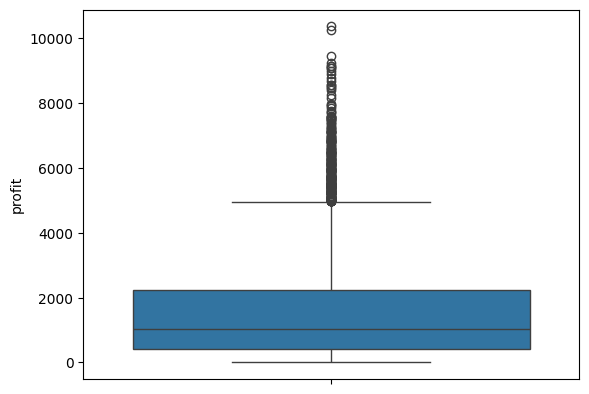

In [30]:
sns.boxplot(df['profit'])

In [31]:
df = df[
    (df['total_sales'] >= lower_limit) &
    (df['total_sales'] <= upper_limit)
]

In [32]:
outliers = df[
    (df['total_sales'] < lower_limit) |
    (df['total_sales'] > upper_limit)
]

print("Outliers:")
print(outliers)

Outliers:
Empty DataFrame
Columns: [order_id, order_date, customer_Name, city, region, product, category, quantity, unit_Price, discount_Percent, total_sales, profit, payment_method, sales_channel, sales_rep]
Index: []


In [33]:
print(df.isnull().sum())

order_id            0
order_date          8
customer_Name       0
city                0
region              0
product             0
category            0
quantity            0
unit_Price          0
discount_Percent    0
total_sales         0
profit              0
payment_method      0
sales_channel       0
sales_rep           0
dtype: int64


In [34]:
print(df[df['order_date'].isnull()])

      order_id order_date         customer_Name            city region  \
717   ORD00718        NaT          Shawn Thomas  Salt Lake City   West   
776   ORD00777        NaT       Jessica Stevens    Indianapolis   East   
962   ORD00963        NaT       William Johnson          Boston  South   
2067  ORD02068        NaT  Christopher Robinson      Birmingham  North   
2078  ORD02079        NaT           Tracy Mckay       Cleveland   West   
2113  ORD02114        NaT        Allison Hanson          Dayton  North   
3000  ORD03001        NaT          Alicia Jones          Dallas  South   
3930  ORD03931        NaT     Richard Contreras        Richmond   West   

         product     category  quantity  unit_Price  discount_Percent  \
717   Headphones  Accessories      10.0         953                 0   
776     Keyboard  Accessories       2.0         734                20   
962     Keyboard  Accessories       7.0         504                10   
2067     Monitor  Electronics       2.0  

In [35]:
df['order_date'] = df['order_date'].ffill()

In [36]:
print(df.isnull().sum())

order_id            0
order_date          0
customer_Name       0
city                0
region              0
product             0
category            0
quantity            0
unit_Price          0
discount_Percent    0
total_sales         0
profit              0
payment_method      0
sales_channel       0
sales_rep           0
dtype: int64


###**Standardize Text**

In [37]:
df['city'] = df['city'].str.title().str.strip()

In [38]:
df['region'] = df['region'].str.title().str.strip()

###**Final Data Check**

In [39]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4943 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          4943 non-null   object        
 1   order_date        4943 non-null   datetime64[ns]
 2   customer_Name     4943 non-null   object        
 3   city              4943 non-null   object        
 4   region            4943 non-null   object        
 5   product           4943 non-null   object        
 6   category          4943 non-null   object        
 7   quantity          4943 non-null   float64       
 8   unit_Price        4943 non-null   int64         
 9   discount_Percent  4943 non-null   int64         
 10  total_sales       4943 non-null   float64       
 11  profit            4943 non-null   float64       
 12  payment_method    4943 non-null   object        
 13  sales_channel     4943 non-null   object        
 14  sales_rep         4943 non-nu

In [40]:
print(df.isnull().sum())

order_id            0
order_date          0
customer_Name       0
city                0
region              0
product             0
category            0
quantity            0
unit_Price          0
discount_Percent    0
total_sales         0
profit              0
payment_method      0
sales_channel       0
sales_rep           0
dtype: int64


In [41]:
print(df.head())

   order_id order_date      customer_Name         city region     product  \
0  ORD00001 2024-08-16         Mark Hodge      Chicago  North       Mouse   
1  ORD00002 2024-04-05      Rhonda Chavez      Detroit  North  Smartwatch   
2  ORD00003 2025-08-26        Daniel Dean  Minneapolis  North      Camera   
3  ORD00004 2024-12-10  Stephanie Wallace  Los Angeles   West      Tablet   
4  ORD00005 2025-04-15          Rick Ruiz    San Diego   West      Tablet   

      category  quantity  unit_Price  discount_Percent  total_sales   profit  \
0  Accessories       1.0        1176                 5       1117.2   429.38   
1    Wearables       7.0         180                 0       1260.0   498.12   
2  Electronics       7.0         952                15       5664.4  1535.73   
3  Electronics       5.0         686                 5       3258.5  1284.35   
4  Electronics      10.0        1133                 0      11330.0  3579.60   

  payment_method sales_channel            sales_rep  
0 

In [42]:
# Save Clean dataset


df.to_csv("sales_data_cleaned.csv", index=False)

print("Data cleaning completed successfully!")

Data cleaning completed successfully!


In [43]:
from google.colab import files

files.download("sales_data_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###**Exploratory Data Analysis (EDA)**

**The objective of this analysis is to:**

- Understand sales distribution
- Analyze profit performance
- Identify top-selling products
- Compare regional sales
- Evaluate sales channels
- Discover monthly trends

In [44]:
df.columns

Index(['order_id', 'order_date', 'customer_Name', 'city', 'region', 'product',
       'category', 'quantity', 'unit_Price', 'discount_Percent', 'total_sales',
       'profit', 'payment_method', 'sales_channel', 'sales_rep'],
      dtype='object')

In [45]:
df['Year'] = df['order_date'].dt.year
df['Month'] = df['order_date'].dt.month
df['Month_Name'] = df['order_date'].dt.month_name()

###**Univariate Analysis**

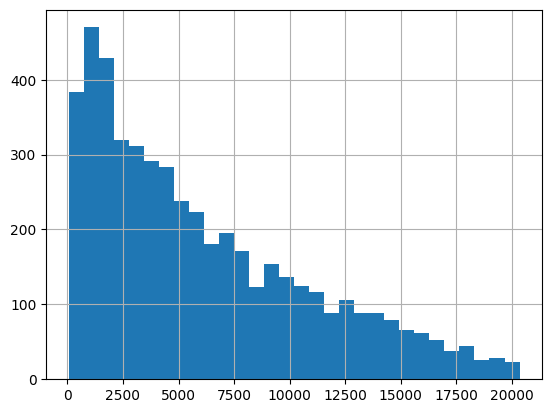

In [46]:
# Sales Distributio

df['total_sales'].hist(bins=30)
plt.show()

###**Profit Distribution**

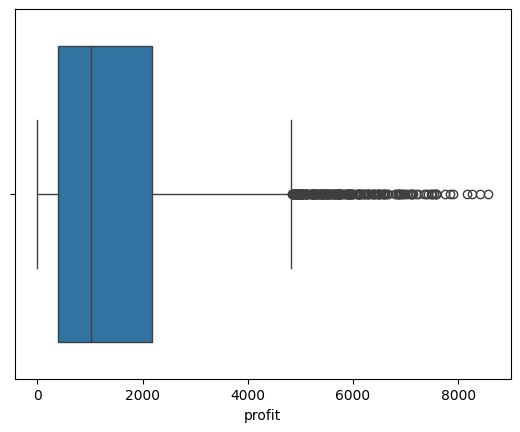

In [47]:
sns.boxplot(x=df['profit'])
plt.show()

###**Payment Method Analysis**

In [48]:
df['payment_method'].value_counts()

,count
payment_method,
Net Banking,1008
Debit Card,1002
UPI,1001
Credit Card,988
Cash,944


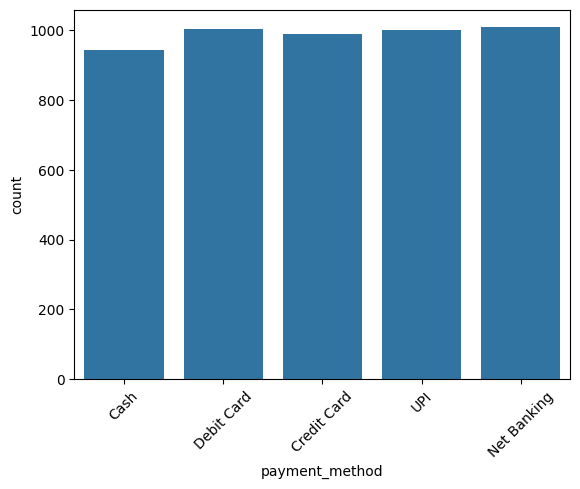

In [49]:
sns.countplot(x='payment_method',data=df)
plt.xticks(rotation=45)
plt.show()

###**Category Analysis**

In [50]:
# Sales by Category

category_sales = df.groupby('category')['total_sales'].sum().sort_values(ascending=False)

category_sales

,total_sales
category,
Electronics,14738612.70
Accessories,9116369.45
Office Equipment,3188188.75
Wearables,3054771.25


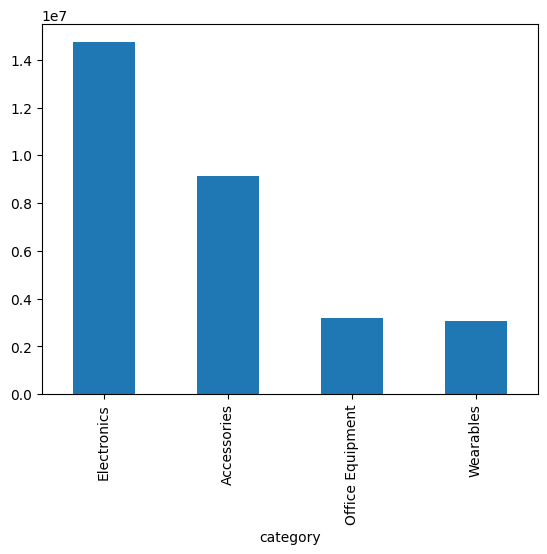

In [51]:
category_sales.plot(kind='bar')
plt.show()

###**Profit by Category**

In [52]:
# Which category generates the highest revenue?

df.groupby('category')['profit'].sum().sort_values(ascending=False)

,profit
category,
Electronics,3593745.99
Accessories,2290912.06
Wearables,781538.87
Office Equipment,781308.92


**Top 10 Products by Sales**

In [53]:
top_products = df.groupby('product')['total_sales'].sum().nlargest(10)

top_products

,total_sales
product,
Laptop,3483487.80
Keyboard,3205851.40
Printer,3188188.75
Mouse,3062197.40
Smartwatch,3054771.25
Tablet,2908613.65
Smartphone,2907255.60
Headphones,2848320.65
Monitor,2783773.00


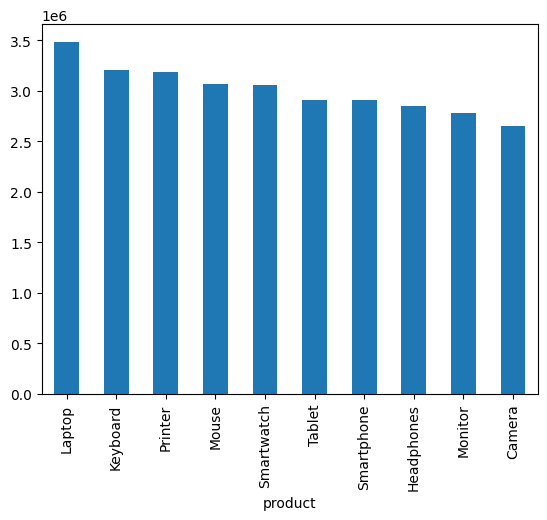

In [54]:
top_products.plot(kind='bar')
plt.show()

###**Geographic Analysis**

In [55]:
# Sales by Region
region_sales = df.groupby('region')['total_sales'].sum()
region_sales

,total_sales
region,
East,7990351.35
North,7154010.90
South,7343923.85
West,7609656.05


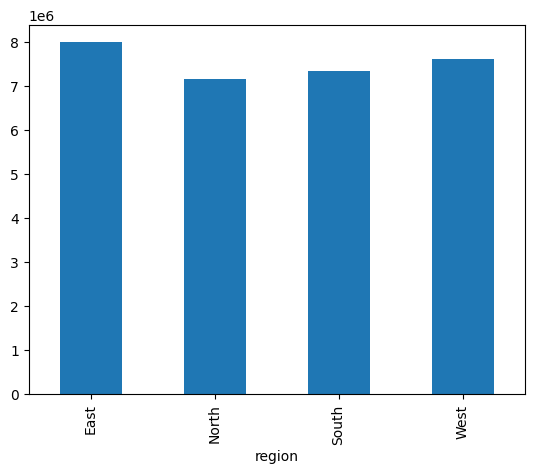

In [56]:
region_sales.plot(kind='bar')
plt.show()

In [57]:
# Sales by City

city_sales = df.groupby('city')['total_sales'].sum().nlargest(10)
city_sales

,total_sales
city,
Long Beach,616383.55
Las Vegas,581788.20
Tucson,566993.50
Boise,560975.60
Oakland,558679.10
Denver,532414.35
San Francisco,503744.10
Reno,491085.90
Spokane,487980.35


###**Time Series Analysis**

In [58]:
# Monthly Sales Trend

monthly_sales = df.groupby('Month_Name')['total_sales'].sum()
monthly_sales

,total_sales
Month_Name,
April,2577336.65
August,2293493.80
December,2723127.35
February,2198251.75
January,2693153.30
July,2495095.10
June,2624138.90
March,2698721.35
May,2671987.80


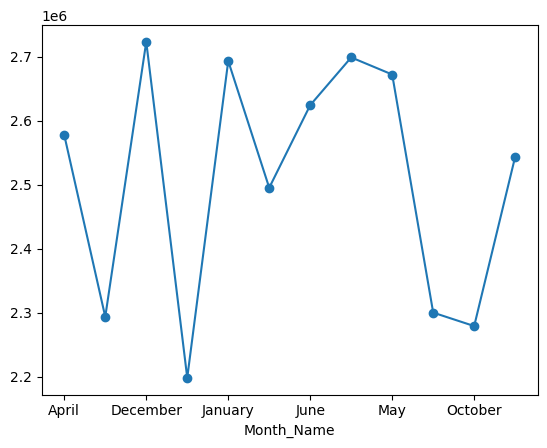

In [59]:
monthly_sales.plot(kind='line',marker='o')
plt.show()

###**Monthly Profit Trend**

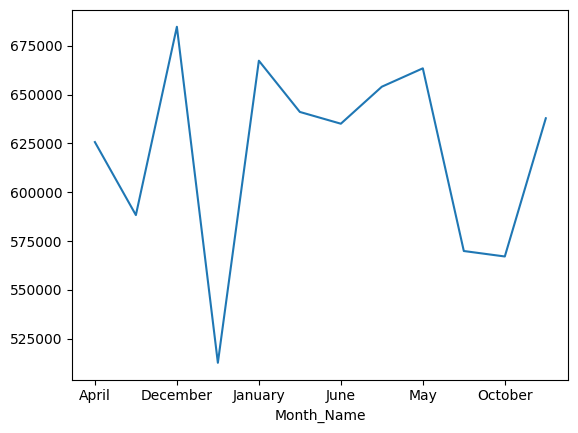

In [60]:
monthly_profit = df.groupby('Month_Name')['profit'].sum()
monthly_profit.plot(kind='line')
plt.show()

###**Sales Channel Analysis**

In [61]:
# Sales Channel Performance

df.groupby('sales_channel')['total_sales'].sum()

,total_sales
sales_channel,
Online,15291374.55
Retail Store,14806567.60


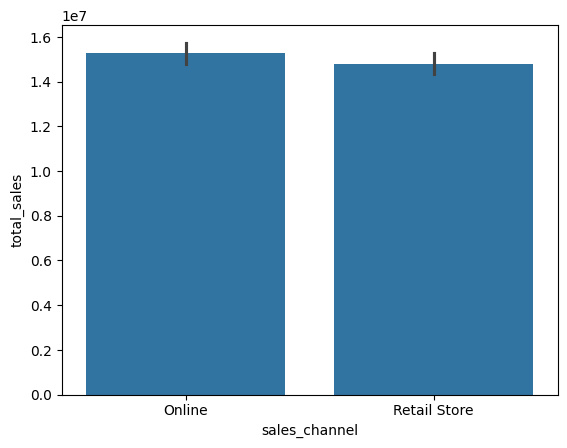

In [62]:
sns.barplot(
    data=df,
    x='sales_channel',
    y='total_sales',
    estimator=sum
)
plt.show()

###**Sales Representative Analysis**

In [63]:
# Top Sales Representatives

sales_rep = df.groupby('sales_rep')['total_sales'].sum().sort_values(ascending=False)
sales_rep.head(10)

,total_sales
sales_rep,
Robert Smith,39270.75
Anthony Harrington,34459.75
Keith Johnson,30161.20
Edward Sanchez,29685.60
Brian Smith,28937.00
Cynthia Johnson,28231.30
Robert Davis,27102.60
Erica Lawrence,26462.70
Brandon Morgan,25513.00


###**Correlation Analysis**

In [64]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()
corr

,quantity,unit_Price,discount_Percent,total_sales,profit
quantity,1.000000,0.002573,0.001068,0.156070,0.128088
unit_Price,0.002573,1.000000,0.009174,0.173378,0.141678
discount_Percent,0.001068,0.009174,1.000000,-0.063018,-0.292947
total_sales,0.156070,0.173378,-0.063018,1.000000,0.852476
profit,0.128088,0.141678,-0.292947,0.852476,1.000000


In [65]:
df[['quantity',
      'unit_Price',
      'discount_Percent',
      'total_sales',
      'profit']].corr()

,quantity,unit_Price,discount_Percent,total_sales,profit
quantity,1.000000,0.002573,0.001068,0.156070,0.128088
unit_Price,0.002573,1.000000,0.009174,0.173378,0.141678
discount_Percent,0.001068,0.009174,1.000000,-0.063018,-0.292947
total_sales,0.156070,0.173378,-0.063018,1.000000,0.852476
profit,0.128088,0.141678,-0.292947,0.852476,1.000000


<Axes: >

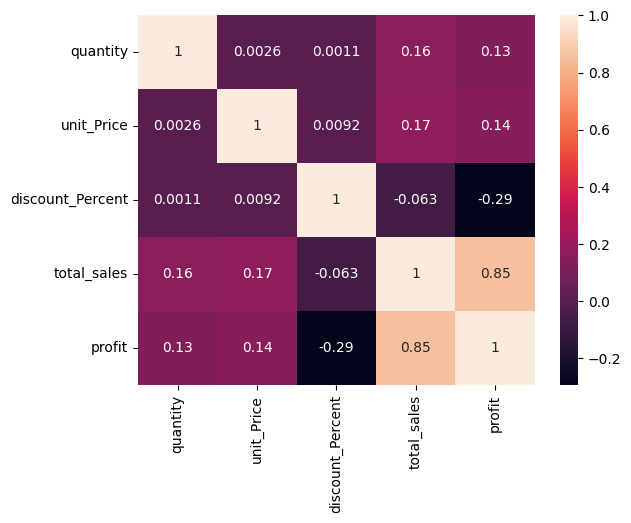

In [66]:
sns.heatmap(corr, annot=True)

###**Top 10 Cities by Revenue**

<Axes: xlabel='city'>

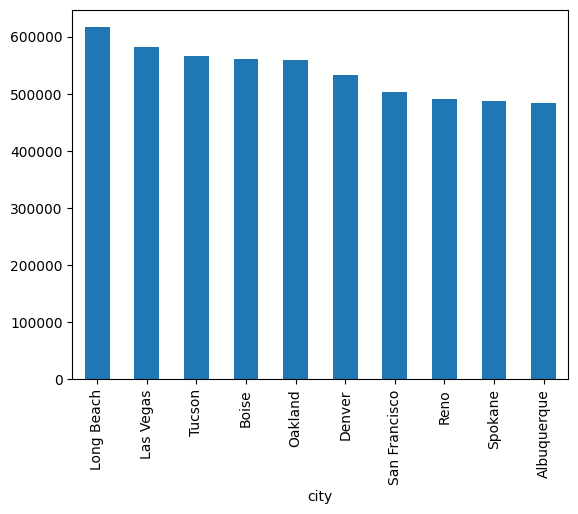

In [67]:
city_sales = df.groupby('city')['total_sales'].sum()\
.sort_values(ascending=False).head(10)

city_sales.plot(kind='bar')

###**Top Sales Representatives**

<Axes: xlabel='sales_rep'>

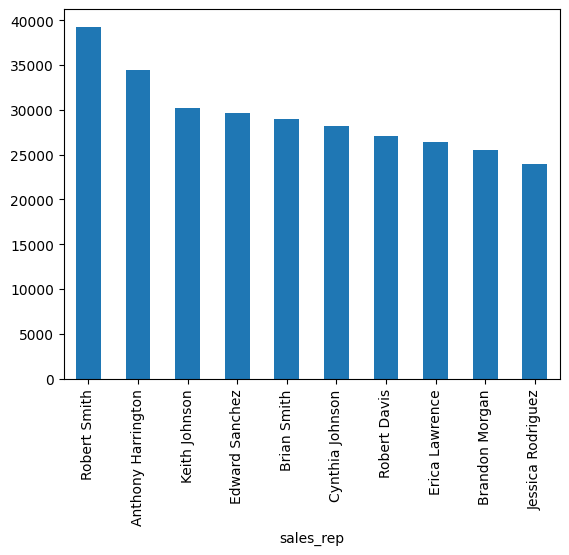

In [68]:
sales_rep = df.groupby('sales_rep')['total_sales'].sum()\
.sort_values(ascending=False).head(10)

sales_rep.plot(kind='bar')

###**Profit Margin**

In [69]:
df['profit_margin'] = (
    df['profit'] /
    df['total_sales']
) * 100

In [70]:
print(df['profit_margin'])

0       38.433584
1       39.533333
2       27.111962
3       39.415375
4       31.593998
          ...    
4995    14.557628
4996    39.465004
4997    34.588235
4998    30.121468
4999    22.417221
Name: profit_margin, Length: 4943, dtype: float64


###**Business Insights & Key Findings**

####**Revenue & Profit**
- Total Revenue generated: ₹31,378,881.70
- Total Profit earned: ₹7,836,169.36

####**Product Performance**
- Top-Selling Product (by Revenue): Laptop
- Revenue Generated by Laptop: ₹3,614,428.80

####**Regional Performance**
- North region generated the highest revenue.
- South region generated the highest profit.

####**Customer & Payment Analysis**
- Credit Card was the most preferred payment method.
- Online sales channel contributed more revenue than Retail.

####**Sales Trends**
- Sales peaked during August.
- Revenue showed steady growth in the second half of the year.

####**Recommendations**
- Increase inventory for top-performing products.
- Focus marketing efforts on high-performing regions.
- Promote online sales channels to maximize revenue.